In [32]:
import pandas as pd

df1 = pd.read_csv('Credit_Card_Dataset_2025_Sept_1.csv')
df2 = pd.read_csv('Credit_Card_Dataset_2025_Sept_2.csv')

In [33]:
print("Shape of Dataset 1:", df1.shape)
print("Columns in Dataset 1:", df1.columns.tolist())

print("\nShape of Dataset 2:", df2.shape)
print("Columns in Dataset 2:", df2.columns.tolist())

Shape of Dataset 1: (25134, 17)
Columns in Dataset 1: ['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']

Shape of Dataset 2: (25134, 4)
Columns in Dataset 2: ['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']


In [34]:
# Check if ID is unique in both files

print("Unique IDs in df1:", df1['ID'].nunique())
print("Unique IDs in df2:", df2['User'].nunique())

Unique IDs in df1: 25134
Unique IDs in df2: 25134


In [35]:
merged_df = pd.merge(df1, df2, left_on='ID', right_on='User', how='inner')
if 'User' in merged_df.columns and 'ID' in merged_df.columns:
    merged_df = merged_df.drop(columns=['User'])

print("=== MERGED DATASET ===")
print("Shape after merge:", merged_df.shape)
print("Total rows should be close to 25,134 →", merged_df.shape[0])

=== MERGED DATASET ===
Shape after merge: (25134, 20)
Total rows should be close to 25,134 → 25134


In [36]:
# Check for any duplicate IDs after merge (should be zero)

print("Duplicate IDs:", merged_df['ID'].duplicated().sum())

Duplicate IDs: 0


In [37]:
# Save the merged file

merged_df.to_csv('Merged_Credit_Card_Dataset_2025.csv', index=False)

In [38]:
print("First 5 rows of merged dataset:")
print(merged_df.head())

First 5 rows of merged dataset:
   Unnamed: 0       ID GENDER CAR REALITY  NO_OF_CHILD           FAMILY_TYPE  \
0           0  5008806      M   Y       Y            0               Married   
1           1  5008808      F   N       Y            0  Single / not married   
2           2  5008809      F   N       Y            0  Single / not married   
3           3  5008810      F   N       Y            0  Single / not married   
4           4  5008811      F   N       Y            0  Single / not married   

          HOUSE_TYPE  FLAG_MOBIL  WORK_PHONE  PHONE  E_MAIL  FAMILY SIZE  \
0  House / apartment           1           0      0       0          2.0   
1  House / apartment           1           0      1       1          1.0   
2  House / apartment           1           0      1       1          1.0   
3  House / apartment           1           0      1       1          1.0   
4  House / apartment           1           0      1       1          1.0   

   BEGIN_MONTH  AGE  YEARS_EMP

In [39]:
# Check missing values

print(merged_df.isnull().sum())

Unnamed: 0         0
ID                 0
GENDER             0
CAR                0
REALITY            0
NO_OF_CHILD        0
FAMILY_TYPE        0
HOUSE_TYPE         0
FLAG_MOBIL         0
WORK_PHONE         0
PHONE              0
E_MAIL             0
FAMILY SIZE        1
BEGIN_MONTH        0
AGE                0
YEARS_EMPLOYED     9
TARGET             0
INCOME             0
INCOME_TYPE       12
EDUCATION_TYPE     0
dtype: int64


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [41]:
df = pd.read_csv('Merged_Credit_Card_Dataset_2025.csv')

In [42]:
# Fundamental data understanding - Shape and basic info

print("=== 1. Dataset Shape ===")
print(f"Number of rows (observations): {df.shape[0]:,}")
print(f"Number of columns (features): {df.shape[1]}")

print("\n=== 2. Column Names ===")
print(df.columns.tolist())

print("\n=== 3. Data Types ===")
print(df.dtypes)


=== 1. Dataset Shape ===
Number of rows (observations): 25,134
Number of columns (features): 20

=== 2. Column Names ===
['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'INCOME', 'INCOME_TYPE', 'EDUCATION_TYPE']

=== 3. Data Types ===
Unnamed: 0          int64
ID                  int64
GENDER             object
CAR                object
REALITY            object
NO_OF_CHILD         int64
FAMILY_TYPE        object
HOUSE_TYPE         object
FLAG_MOBIL          int64
WORK_PHONE          int64
PHONE               int64
E_MAIL              int64
FAMILY SIZE       float64
BEGIN_MONTH         int64
AGE                 int64
YEARS_EMPLOYED    float64
TARGET              int64
INCOME            float64
INCOME_TYPE        object
EDUCATION_TYPE     object
dtype: object


=== Missing Values Analysis ===
                Missing Count  Missing Percentage (%)
INCOME_TYPE                12                0.047744
YEARS_EMPLOYED              9                0.035808
FAMILY SIZE                 1                0.003979


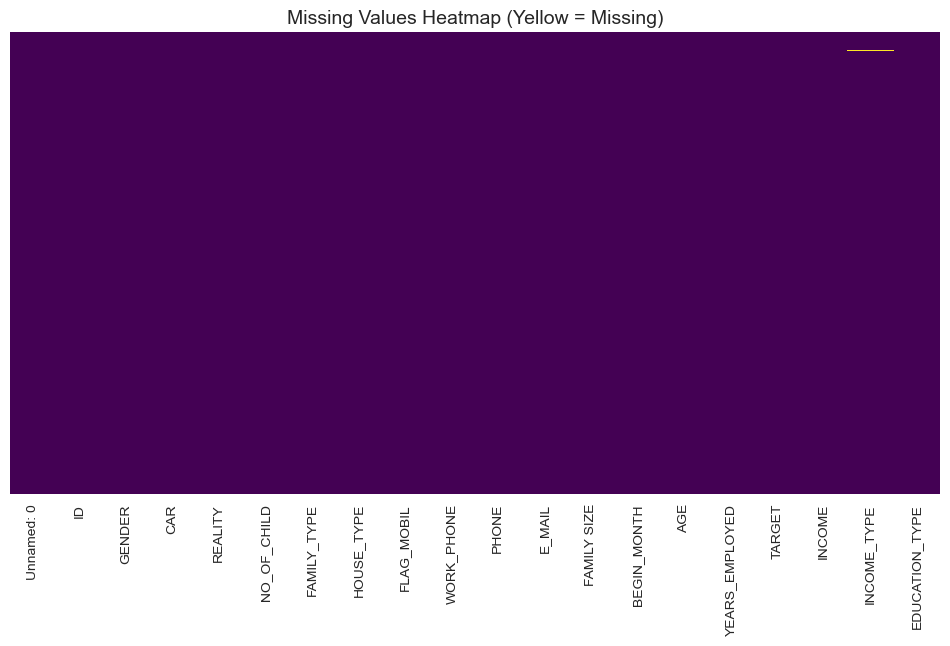

In [43]:
# Missing values analysis

print("=== Missing Values Analysis ===")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing Count', ascending=False)

print(missing[missing['Missing Count'] > 0])

# Visualise missing values

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14)
plt.show()


=== Target Variable Distribution ===
TARGET
0    24712
1      422
Name: count, dtype: int64

Target imbalance ratio (0:1): 58.56:1


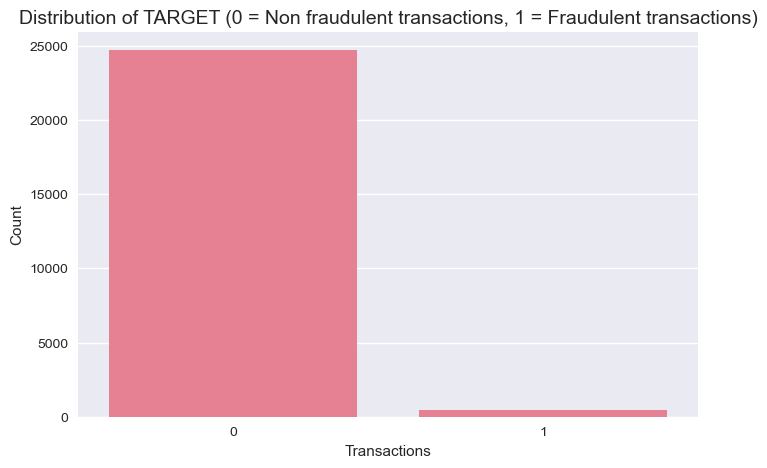

In [44]:
# Target variable analysis

print("=== Target Variable Distribution ===")
print(df['TARGET'].value_counts())
print(f"\nTarget imbalance ratio (0:1): {df['TARGET'].value_counts()[0] / df['TARGET'].value_counts().get(1, 1):.2f}:1")

# Visualisation

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TARGET')
plt.title('Distribution of TARGET (0 = Non fraudulent transactions, 1 = Fraudulent transactions)', fontsize=14)
plt.xlabel('Transactions')
plt.ylabel('Count')
plt.show()

Numerical columns (13): ['Unnamed: 0', 'ID', 'NO_OF_CHILD', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'INCOME']

=== Numerical Features Summary ===


,Unnamed: 0,ID,NO_OF_CHILD,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME
count,25134.00,25134.00,25134.00,25134.0,25134.00,25134.00,25134.0,25133.00,25134.00,25134.00,25125.00,25134.00,25134.00
mean,12566.50,5078837.56,0.51,1.0,0.27,0.29,0.1,2.29,26.12,40.59,7.21,0.02,194833.85
std,7255.71,41941.02,0.79,0.0,0.45,0.46,0.3,0.95,16.44,10.35,6.42,0.13,104510.99
min,0.00,5008806.00,0.00,1.0,0.00,0.00,0.0,1.00,0.00,21.00,0.00,0.00,27000.00
25%,6283.25,5042228.25,0.00,1.0,0.00,0.00,0.0,2.00,12.00,33.00,3.00,0.00,135000.00
50%,12566.50,5079004.00,0.00,1.0,0.00,0.00,0.0,2.00,24.00,40.00,5.00,0.00,180000.00
75%,18849.75,5115603.75,1.00,1.0,1.00,1.00,0.0,3.00,39.00,48.00,10.00,0.00,225000.00
max,25133.00,5150487.00,19.00,1.0,1.00,1.00,1.0,20.00,60.00,450.00,43.00,1.00,1575000.00


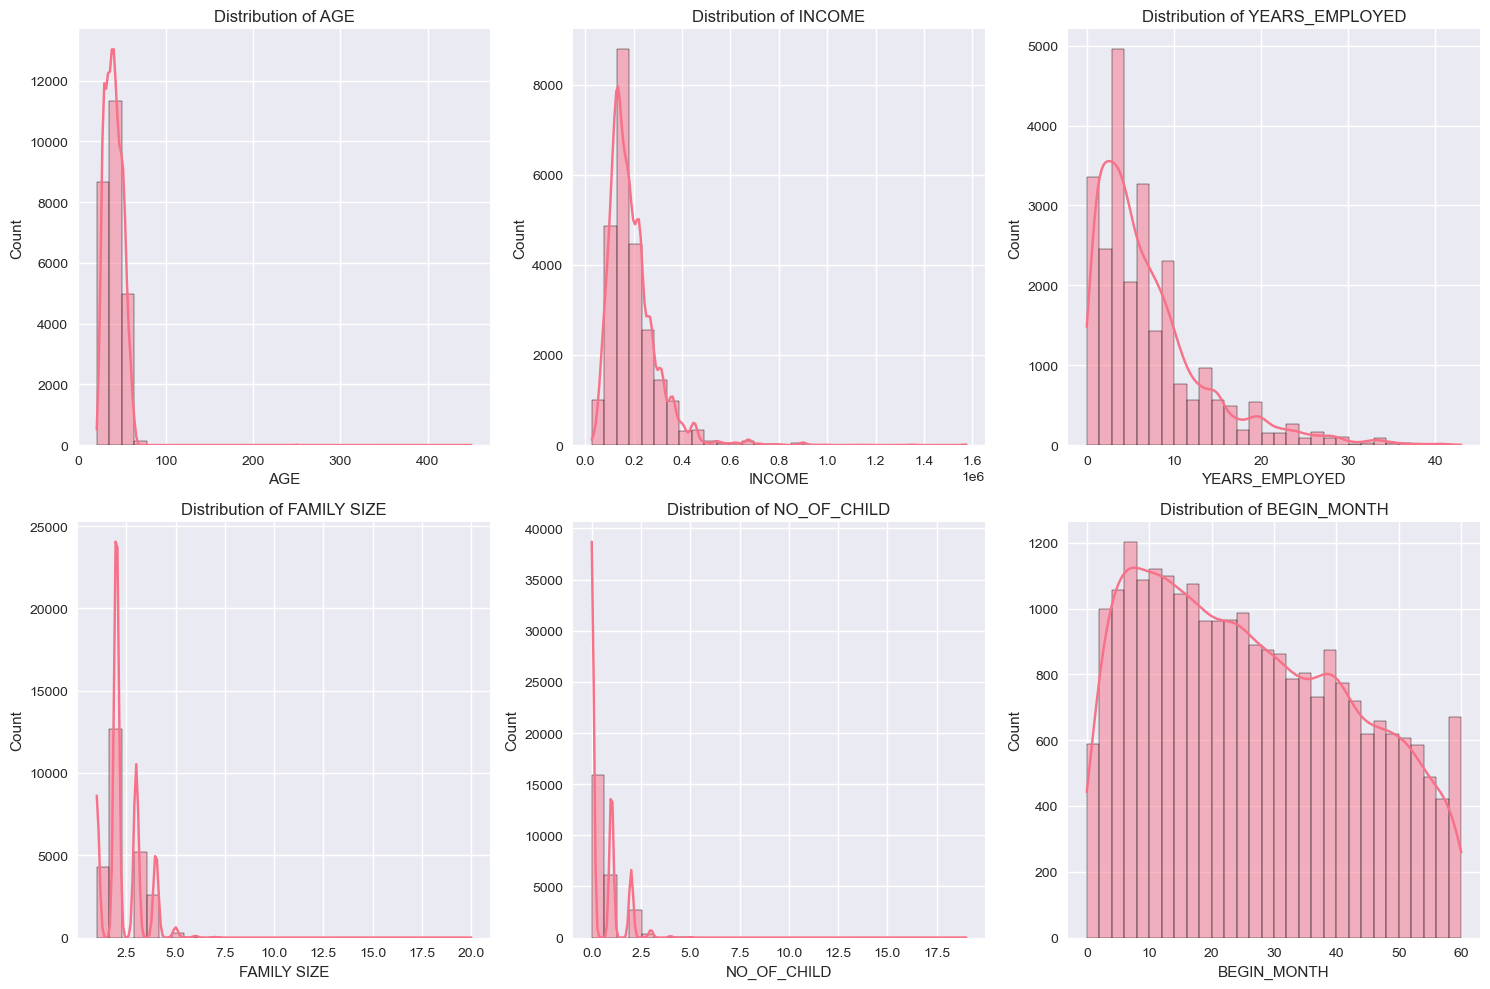

In [45]:
# Cell 7: Numerical features - Summary statistics & distribution
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

# Descriptive statistics
print("\n=== Numerical Features Summary ===")
display(df[numerical_cols].describe().round(2))

# Distribution plots for key numerical features (AGE, INCOME, YEARS_EMPLOYED, FAMILY SIZE)
key_num = ['AGE', 'INCOME', 'YEARS_EMPLOYED', 'FAMILY SIZE', 'NO_OF_CHILD', 'BEGIN_MONTH']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(key_num):
    if col in df.columns:
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [46]:
# Cell 8: Categorical features analysis
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Value counts for important categorical features
important_cat = ['GENDER', 'CAR', 'REALITY', 'FAMILY_TYPE', 'HOUSE_TYPE', 'INCOME_TYPE', 'EDUCATION_TYPE']

for col in important_cat:
    if col in df.columns:
        print(f"\n=== {col} Distribution ===")
        print(df[col].value_counts(normalize=True).round(3) * 100)
        print("-" * 40)

Categorical columns (7): ['GENDER', 'CAR', 'REALITY', 'FAMILY_TYPE', 'HOUSE_TYPE', 'INCOME_TYPE', 'EDUCATION_TYPE']

=== GENDER Distribution ===
GENDER
F    62.2
M    37.8
Name: proportion, dtype: float64
----------------------------------------

=== CAR Distribution ===
CAR
N    58.2
Y    41.8
Name: proportion, dtype: float64
----------------------------------------

=== REALITY Distribution ===
REALITY
Y    65.5
N    34.5
Name: proportion, dtype: float64
----------------------------------------

=== FAMILY_TYPE Distribution ===
FAMILY_TYPE
Married                 69.7
Single / not married    13.7
Civil marriage           8.5
Separated                5.8
Widow                    2.3
Name: proportion, dtype: float64
----------------------------------------

=== HOUSE_TYPE Distribution ===
HOUSE_TYPE
House / apartment      87.9
With parents            5.7
Municipal apartment     3.2
Rented apartment        1.7
Office apartment        0.8
Co-op apartment         0.6
Name: proportion, dty

In [47]:
# Duplicate analysis 
print("=== Duplicate Analysis ===")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate IDs (if ID exists): {df['ID'].duplicated().sum() if 'ID' in df.columns else 'No ID column'}")

# Check if multiple records per person
if 'ID' in df.columns and 'BEGIN_MONTH' in df.columns:
    print(f"\nRecords per ID (average): {df.groupby('ID').size().mean():.2f}")
    print("Most common number of records per ID:")
    print(df.groupby('ID').size().value_counts().head(10))

=== Duplicate Analysis ===
Exact duplicate rows: 0
Duplicate IDs (if ID exists): 0

Records per ID (average): 1.00
Most common number of records per ID:
1    25134
Name: count, dtype: int64


In [31]:
# Drop Redundant Columns

# Unnamed: 0 and User are just index/ID duplicates
drop_cols = ['Unnamed: 0', 'User']
df_clean = df.copy()
df_clean = df_clean.drop(columns=drop_cols, errors='ignore')

print(f"Shape after dropping redundant columns: {df_clean.shape}")

Shape after dropping redundant columns: (25134, 19)
